In [39]:
# --- Section 1: Imports & Load ---
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_parquet("C:\\Users\\PC\\balnce-sheet-ml\\data\\processed\\wide.parquet")
print("Shape:", df.shape)
df.head()


Shape: (13764, 6801)


,cik,end,AcceleratedShareRepurchaseProgramAdjustment,AcceleratedShareRepurchasesFinalPricePaidPerShare,AcceleratedShareRepurchasesInitialPricePaidPerShare,AcceleratedShareRepurchasesSettlementPaymentOrReceipt,AccountsAndFinancingReceivableAllowanceForCreditLoss,AccountsAndNotesReceivableNet,AccountsAndOtherReceivablesNetCurrent,AccountsNotesAndLoansReceivableNetCurrent,...,WeightedAverageRateDomesticDepositMoneyMarket,WeightedAverageRateDomesticDepositSavings,WithdrawalFromContractHoldersFunds,WorkersCompensationDiscountAmount,WorkersCompensationDiscountPercent,WorkersCompensationDiscountPriorYearAmount,WorkersCompensationLiabilityCurrent,WorkersCompensationLiabilityCurrentAndNoncurrent,WorkersCompensationLiabilityNoncurrent,WriteOffOfDeferredDebtIssuanceCost
0,0000027430,2024-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0000027430,2024-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0000027430,2024-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0000027430,2025-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0000027430,2025-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# --- Section 2: Basic Sanity Checks ---
print("Unique companies:", df['cik'].nunique())
print("Reporting periods per company:", df.groupby('cik')['end'].nunique().describe())
print("Overall missing ratio:", df.isna().mean().mean())


Unique companies: 223
Reporting periods per company: count    223.000000
mean      61.721973
std       33.530863
min        1.000000
25%       31.500000
50%       71.000000
75%       84.500000
max      183.000000
Name: end, dtype: float64
Overall missing ratio: 0.9836385968335255


In [41]:
# --- Section 3: Coverage of Core Concepts ---
core = ["Assets","Liabilities","StockholdersEquity","Revenues","NetIncomeLoss"]
print(df[core].notna().sum())


Assets                9522
Liabilities           6515
StockholdersEquity    9215
Revenues              4704
NetIncomeLoss         9606
dtype: int64


In [42]:
# --- Section 4: Most Reported Concepts ---
coverage = df.notna().mean().sort_values(ascending=False)
print("Top 20 most reported concepts:\n", coverage.head(20))
print("Bottom 20 least reported concepts:\n", coverage.tail(20))


Top 20 most reported concepts:
 cik                                                1.000000
end                                                1.000000
NetIncomeLoss                                      0.697908
Assets                                             0.691805
LiabilitiesAndStockholdersEquity                   0.689334
IncomeTaxExpenseBenefit                            0.687446
CashAndCashEquivalentsAtCarryingValue              0.685266
RetainedEarningsAccumulatedDeficit                 0.674876
StockholdersEquity                                 0.669500
NetCashProvidedByUsedInOperatingActivities         0.666158
NetCashProvidedByUsedInFinancingActivities         0.663688
NetCashProvidedByUsedInInvestingActivities         0.657948
EarningsPerShareBasic                              0.636080
WeightedAverageNumberOfSharesOutstandingBasic      0.634554
EarningsPerShareDiluted                            0.625400
WeightedAverageNumberOfDilutedSharesOutstanding    0.621622
Property

In [43]:
# --- Section 5: Company Coverage ---
# Count non-null values per company for key concepts
company_coverage = df.groupby('cik')[['Assets','Liabilities','NetIncomeLoss']].count()
print(company_coverage.head())

# Filter companies with at least 4 valid periods of Assets
long_companies = company_coverage[company_coverage['Assets'] >= 4].index
print("Companies with >=4 valid Assets periods:", len(long_companies))


            Assets  Liabilities  NetIncomeLoss
cik                                           
0000027430       0            0              0
10048           58           58             48
10254           51           21             54
10329           58            0             64
10456           67           32             71
Companies with >=4 valid Assets periods: 208


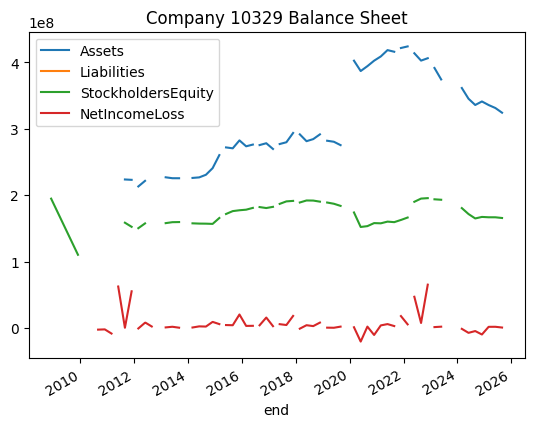

In [61]:
# --- Section 6: Plot Balance Sheet for One Company ---
sample_cik = long_companies[2]
company = df[df['cik'] == sample_cik].set_index('end')
company[['Assets','Liabilities','StockholdersEquity','NetIncomeLoss']].plot(title=f"Company {sample_cik} Balance Sheet")
plt.show()


In [69]:
print(df.columns[:20])   # preview first 20 columns


Index(['cik', 'end', 'AcceleratedShareRepurchaseProgramAdjustment',
       'AcceleratedShareRepurchasesFinalPricePaidPerShare',
       'AcceleratedShareRepurchasesInitialPricePaidPerShare',
       'AcceleratedShareRepurchasesSettlementPaymentOrReceipt',
       'AccountsAndFinancingReceivableAllowanceForCreditLoss',
       'AccountsAndNotesReceivableNet',
       'AccountsAndOtherReceivablesNetCurrent',
       'AccountsNotesAndLoansReceivableNetCurrent', 'AccountsPayable',
       'AccountsPayableAndAccruedLiabilities',
       'AccountsPayableAndAccruedLiabilitiesCurrent',
       'AccountsPayableAndAccruedLiabilitiesCurrentAndNoncurrent',
       'AccountsPayableAndAccruedLiabilitiesFairValueDisclosure',
       'AccountsPayableAndAccruedLiabilitiesNoncurrent',
       'AccountsPayableAndOtherAccruedLiabilities',
       'AccountsPayableAndOtherAccruedLiabilitiesCurrent',
       'AccountsPayableCurrent', 'AccountsPayableCurrentAndNoncurrent'],
      dtype='object')
